In [70]:
# Load model directly
from transformers import AutoImageProcessor, MobileViTForSemanticSegmentation
import rasterio
import tensorflow as tf
import keras_hub as hub
import keras
import numpy as np
import matplotlib.pyplot as plt

import os
import zipfile

In [ ]:

%pip  install tensorflow-text
%pip install transformer rasterio tensorflow keras_hub

ERROR: Could not find a version that satisfies the requirement transformer (from versions: none)
ERROR: No matching distribution found for transformer


In [71]:
import rasterio
path = "/content/data-20260219T221057Z-1-001.zip"
print(os.path.exists(path))
extract_path="/content/"
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print(f"Extracted to {extract_path}")
# extract_path="SatelliteData/data"
print(os.path.exists(extract_path))
images=[]
masks=[]
for root, dirs, filenames in os.walk(extract_path):
    if "images" in root:
        for filename in filenames:
            images.append(os.path.join(root, filename))
    elif "labels" in root:
        for filename in filenames:
            # print(filename)
            if'_' in filename:
                continue
            masks.append(os.path.join(root, filename))
images.sort()  # sorts by filename
masks.sort()   # sorts by filename
# for i in range(len(images)):
#     print(images[i])
#     print(masks[i])

True
Extracted to /content/
True


In [ ]:
print("Number of images:", len(images))
print("Number of masks:", len(masks))

Number of images: 306
Number of masks: 306


In [73]:
from statistics import mean
Image_with_ndwi = []
dataset_mean=[]
dataset_std=[]
loaded_masks=[]
# normalized_images=[]
def preprocessing(images, masks):
  mean={}
  for i in range(len(images)):
     # print(f"Image:{images[i]}")
     with rasterio.open(images[i]) as src:
          image = src.read((range(1,13))).transpose(1, 2, 0)
          # print("image")
          # print(image.shape)
          green=image[:,:,2]
          swir2=image[:,:,6]
          ndwi = (green - swir2) / (swir2 + green + 1e-6)
          ndwi = np.expand_dims(ndwi, axis=-1)
          image_ndwi = np.concatenate((image, ndwi), axis=-1)
          Image_with_ndwi.append(image_ndwi)
          #calculate mean for each band for the current image
          for b in range(image_ndwi.shape[2]):
             value= mean.get(f"band_{b}")
             if value is None:
                mean[f"band_{b}"] = []
             mean[f"band_{b}"].append(np.mean(image_ndwi[:,:,b]))


     with rasterio.open(masks[i]) as src:
          mask = src.read(1)
          mask = np.expand_dims(mask, axis=-1)
          loaded_masks.append(mask)

  # Image_array = np.array(Image_with_ndwi)
  # masks_array = np.array(loaded_masks)
  # plt.figure(figsize=(12,4))
  # plt.subplot(1,2,1)
  # plt.title("Image (first band)")
  # plt.imshow(Image_array[1][:,:,10])
  # plt.colorbar()
  # plt.subplot(1,2,2)
  # plt.title("GT Mask")
  # plt.imshow(masks_array[1][:,:,0], cmap="gray")
  # plt.show()

def normalization(Image_with_ndwi):
    # Stack all images for global stats
    Image_stack = np.stack(Image_with_ndwi, axis=0).astype(np.float32)
    dataset_mean = Image_stack.mean(axis=(0,1,2))
    dataset_std  = Image_stack.std(axis=(0,1,2))

    normalized_images = []
    for img in Image_with_ndwi:
        norm_img = (img.astype(np.float32) - dataset_mean) / dataset_std
        normalized_images.append(norm_img)

    normalized_images = np.array(normalized_images)

    # masks_array = np.array(loaded_masks)
    # plt.figure(figsize=(12,4))
    # plt.subplot(1,2,1)
    # plt.title("Image (first band)")
    # plt.imshow(normalized_images[1][:,:,10])
    # plt.colorbar()
    # plt.subplot(1,2,2)
    # plt.title("GT Mask")
    # plt.imshow(masks_array[1][:,:,0], cmap="gray")
    # plt.show()
    # print("Before normalization (band 10):")
    # print("Min:", Image_stack[1,:,:,10].min())
    # print("Max:", Image_stack[1,:,:,10].max())
    # print("Mean:", Image_stack[1,:,:,10].mean())
    # print("Std:", Image_stack[1,:,:,10].std())

    # print("\nAfter normalization (band 10):")
    # print("Min:", normalized_images[1,:,:,10].min())
    # print("Max:", normalized_images[1,:,:,10].max())
    # print("Mean:", normalized_images[1,:,:,10].mean())
    # print("Std:", normalized_images[1,:,:,10].std())
    print(dataset_mean)
    print(dataset_std)
    return normalized_images






In [74]:
preprocessing(images, masks)
normalized_images=normalization(Image_with_ndwi)
numpy_masks=np.array(loaded_masks)


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


[ 396.46753   494.62097   822.32      973.6752   2090.11     1964.0497
 1351.274     102.73967   141.80379   300.74142    35.10254     9.753333
  -80.3108  ]
[2.7006653e+02 3.2597922e+02 4.1812164e+02 5.8670300e+02 1.0559849e+03
 1.1914220e+03 9.6176227e+02 4.8804016e+01 1.3649807e+03 4.9603885e+02
 2.0184523e+01 2.7758301e+01 2.2802358e+05]


In [ ]:
print(np.array(normalized_images).shape)
print(np.array(numpy_masks).shape)
dataset=tf.data.Dataset.from_tensor_slices((normalized_images, numpy_masks))
dataset = dataset.shuffle(100).batch(8)
train_size = int(0.8* len(dataset))
train_dataset = dataset.take(train_size)
test_dataset   = dataset.skip(train_size)

(306, 128, 128, 13)
(306, 128, 128, 1)


In [ ]:
def Model():
  inputs = keras.Input(shape=(128, 128, 13))
  x=keras.layers.Conv2D(3, (1, 1), padding='same')(inputs)
# 1. Load the COMPLETE pre-trained model (Head + Backbone)
  base_model = hub.models.DeepLabV3ImageSegmenter.from_preset(
      "deeplab_v3_plus_resnet50_pascalvoc"
  )
  base_model.trainable = True
  base_model.backbone.trainable = True

    # Recursively set all layers to trainable
  for layer in base_model.backbone.layers:
       layer.trainable = True
       print(f"{layer}-{True}")

  x = base_model.backbone(x)
  x=keras.layers.Conv2D(1, 1, activation='sigmoid')(x)
  x = keras.layers.Resizing(128, 128)(x)
  model = keras.Model(inputs, x)

  return model

model=Model()
for i, layer in enumerate(model.layers):
    if hasattr(layer, 'trainable'):
        print(f"Layer {i}: {layer.name} - Trainable: {layer.trainable}")
print("\nNon-trainable layers:")
for layer in model.layers:
    if hasattr(layer, 'layers'):
        for sublayer in layer.layers:
            if not sublayer.trainable:
                print(f"  {sublayer.name} - Trainable: {sublayer.trainable}")
    elif not layer.trainable:
        print(f"  {layer.name} - Trainable: {layer.trainable}")
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 185 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


<InputLayer name=inputs, built=True>-True
<Functional name=functional, built=True>-True
<Conv2D name=decoder_conv, built=True>-True
<SpatialPyramidPooling name=spatial_pyramid_pooling, built=True>-True
<BatchNormalization name=decoder_norm, built=True>-True
<UpSampling2D name=encoder_output_upsampling, built=True>-True
<ReLU name=decoder_relu, built=True>-True
<Concatenate name=encoder_decoder_concat, built=True>-True
<Conv2D name=segmentation_head_conv, built=True>-True
<BatchNormalization name=segmentation_head_norm, built=True>-True
<ReLU name=segmentation_head_relu, built=True>-True
<UpSampling2D name=backbone_output_upsampling, built=True>-True
Layer 0: input_layer_1 - Trainable: True
Layer 1: conv2d_1 - Trainable: True
Layer 2: deep_lab_v3_backbone - Trainable: True
Layer 3: conv2d_2 - Trainable: True
Layer 4: resizing - Trainable: True

Non-trainable layers:


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 13)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 3)    │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_lab_v3_backbone            │ (None, 128, 128, 256)  │    39,190,656 │
│ (DeepLabV3Backbone)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 1)    │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 128, 128, 1)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,190,955 (149.50 MB)

 Trainable params: 39,134,155 (149.28 MB)

 Non-trainable params: 56,800 (221.88 KB)

In [ ]:
from keras.src.metrics.accuracy_metrics import accuracy
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall,F1Score

precision_metric = Precision(name='precision')
recall_metric = Recall(name='recall')
F1Score_metric=F1Score(name='F1Score')
binary_accuracy=BinaryAccuracy(name='accuracy')

def dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)

    smooth = 1e-6
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)
model=Model()
model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=[tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5),
    precision_metric,
    recall_metric,
    binary_accuracy]
)
model.fit(train_dataset, epochs=10)





<InputLayer name=inputs, built=True>-True
<Functional name=functional_16, built=True>-True
<Conv2D name=decoder_conv, built=True>-True
<SpatialPyramidPooling name=spatial_pyramid_pooling_2, built=True>-True
<BatchNormalization name=decoder_norm, built=True>-True
<UpSampling2D name=encoder_output_upsampling, built=True>-True
<ReLU name=decoder_relu, built=True>-True
<Concatenate name=encoder_decoder_concat, built=True>-True
<Conv2D name=segmentation_head_conv, built=True>-True
<BatchNormalization name=segmentation_head_norm, built=True>-True
<ReLU name=segmentation_head_relu, built=True>-True
<UpSampling2D name=backbone_output_upsampling, built=True>-True
Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 63s 212ms/step - accuracy: 0.7420 - binary_io_u_1: 0.4384 - loss: 1.0013 - precision: 0.5433 - recall: 0.6993
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.8565 - binary_io_u_1: 0.5476 - loss: 0.7398 - precision: 0.7939 - recall: 0.6391
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 1

In [ ]:
eval = model.evaluate(test_dataset)
# print(f"test loss : {eval[0]}  , iou_metric : {eval[1]}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 888ms/step - accuracy: 0.9393 - binary_io_u_1: 0.7610 - loss: 0.3358 - precision: 0.9015 - recall: 0.8298


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Function to compute IoU
def iou_score(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    if union == 0:
        return 1.0  # perfect if no water in both
    return intersection / union

In [ ]:
model.save("segmentation_model2.h5")

In [ ]:
from google.colab import files
files.download("segmentation_model2.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


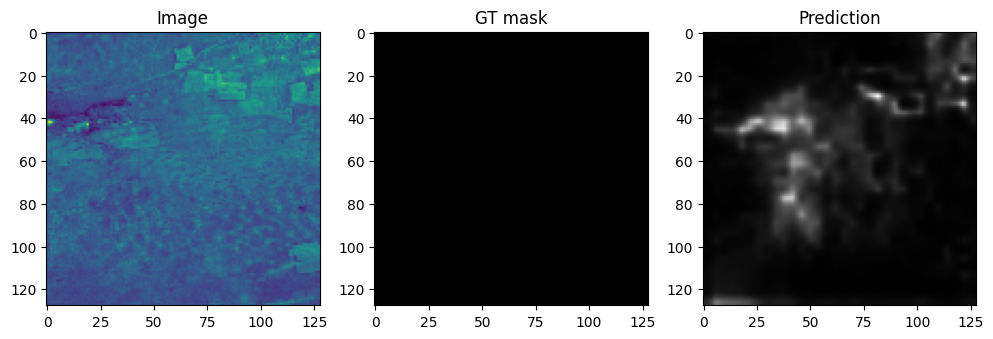

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


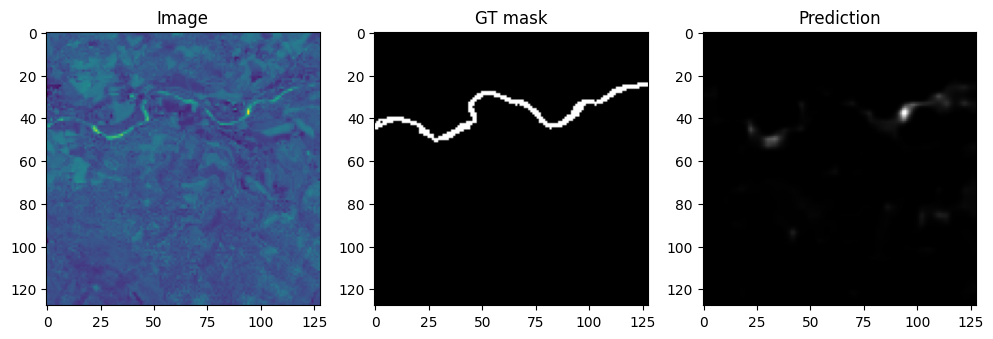

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


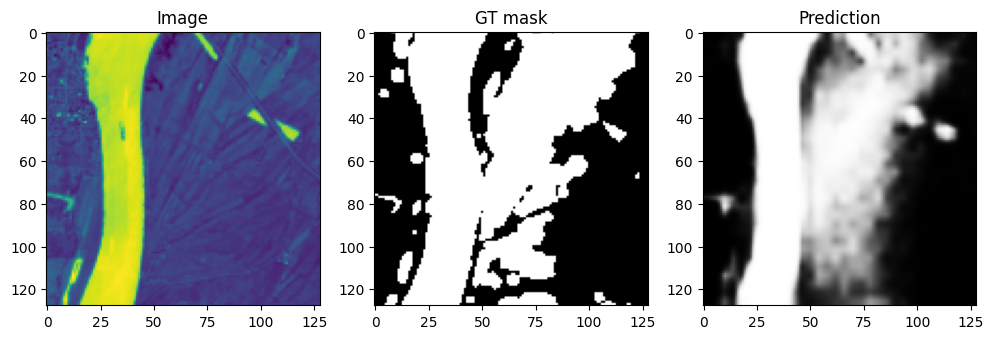

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


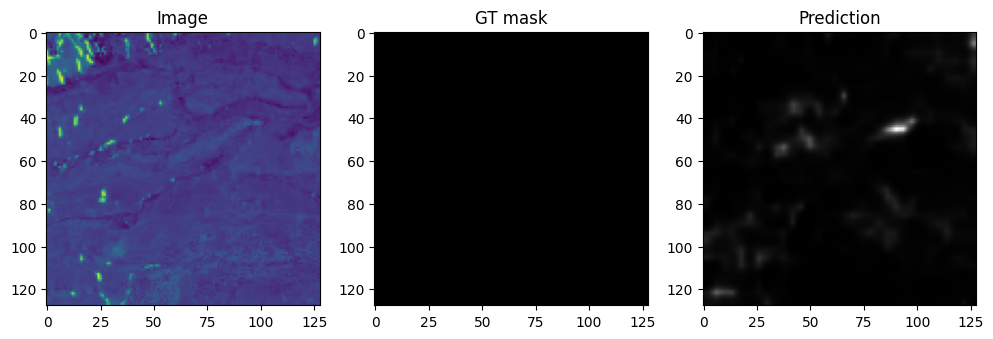

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


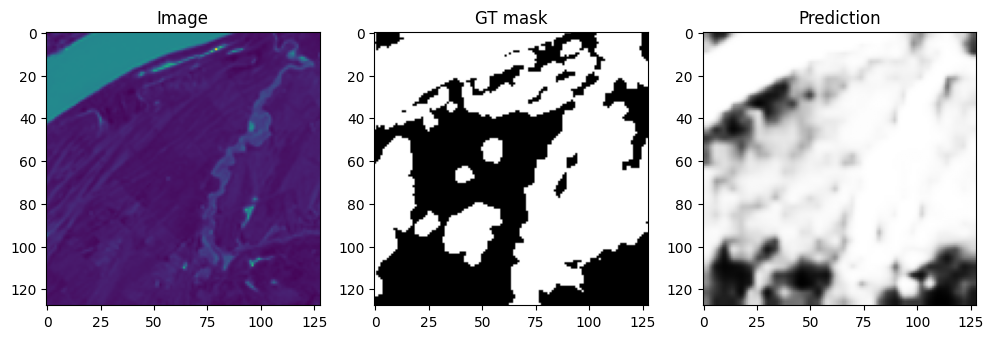

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


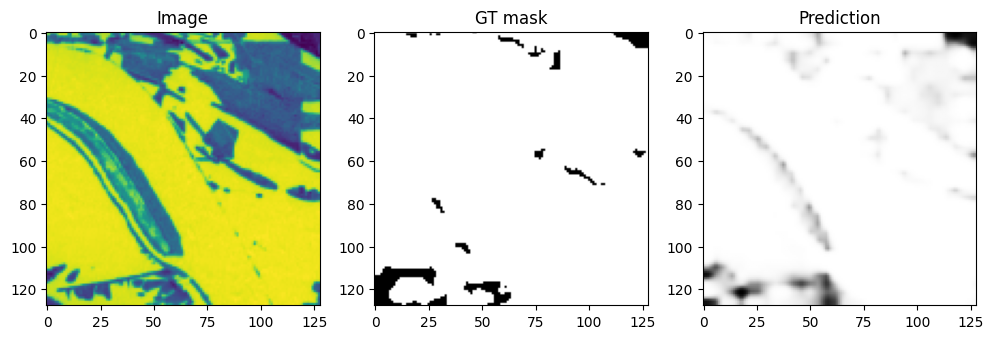

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


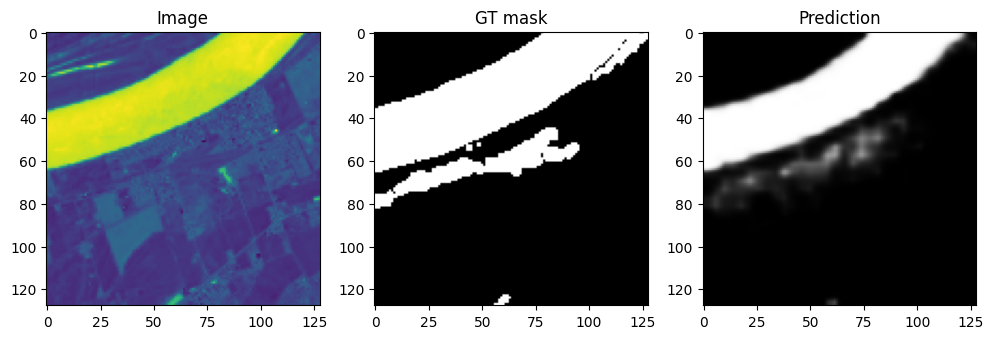

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


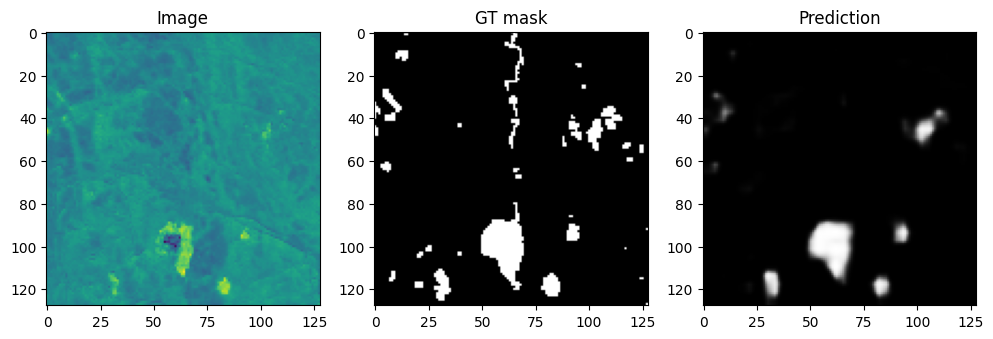

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_true_list=[]
y_pred_list=[]
ious, precisions, recalls, f1s = [], [], [], []

for image,label in test_dataset:
    predictions=model.predict(image)
    mask=predictions[0, :, :, 0]
    threshold = 0.5
    binary_mask = (mask > threshold).astype(np.uint8)
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(image[0][:,:,12])

    plt.subplot(1,3,2)
    plt.title("GT mask")
    plt.imshow(label[0][:,:,0], cmap="gray")

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow((binary_mask), cmap="gray")

    plt.show()



In [ ]:
!unzip -t /content/segmentation_model.keras

Archive:  /content/segmentation_model.keras
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/segmentation_model.keras or
        /content/segmentation_model.keras.zip, and cannot find /content/segmentation_model.keras.ZIP, period.
